In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, recall_score,f1_score,roc_curve, auc,precision_score ,classification_report,confusion_matrix
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import re
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
import torchtext
from torchtext.data.utils import get_tokenizer
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE, ADASYN
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings("ignore")
import time
from sklearn.utils import shuffle

d:\miniconda3\envs\cnneopp\lib\site-packages\torchtext\data\__init__.py:4: UserWarning: 
/!\ IMPORTANT WARNING ABOUT TORCHTEXT STATUS /!\ 
Torchtext is deprecated and the last released version will be 0.18 (this one). You can silence this warning by calling the following at the beginnign of your scripts: `import torchtext; torchtext.disable_torchtext_deprecation_warning()`
  warnings.warn(torchtext._TORCHTEXT_DEPRECATION_MSG)


In [2]:
data=pd.read_excel('../training_data/training_data.xlsx')
data['HLA type']=data['HLA type'].str.replace('*','')
data['HLA type']=data['HLA type'].str.replace(' ','')
data['HLA type']=data['HLA type'].str.replace('\xa0','')
data.head()

,HLA type,Mutated Peptide,Feature 1,Feature 2,Feature 3,Feature 4,Feature 5,Feature 6,Feature 7,Feature 8,Feature 9,Feature 10,Feature 11,label
0,HLA-A02:05,RLFPGLTIKI,0.950510,0.980,0.856370,0.2242,0.7640,6.95,1.15744,2290.86,0.07190,0.759485,0.95,1
1,HLA-A01:01,FLEGNEVGKTY,0.964270,2.384,0.516560,0.2542,0.0880,-6.49,1.25634,2290.07,0.07058,0.229257,-8.59,1
2,HLA-A01:01,LSEEAILGFEY,0.959551,2.776,0.995299,0.0517,0.6204,3.96,1.27036,2257.47,0.47935,1.015717,5.16,1
3,HLA-A01:01,STDVDKTAASY,0.973571,2.664,1.036654,0.0155,0.6681,-8.61,1.15713,2195.41,-0.12867,1.230159,-2.51,1
4,HLA-A01:01,FSEDTTDKGIY,0.776510,2.470,0.910460,0.0181,0.2870,-11.05,1.27528,2294.10,0.05538,0.538690,-8.85,1


In [3]:
def trans_Mutated(x):
  x=x+'X'*(11-len(x))
  return x

data['M']=data['Mutated Peptide'].apply(trans_Mutated)
data.head()

,HLA type,Mutated Peptide,Feature 1,Feature 2,Feature 3,Feature 4,Feature 5,Feature 6,Feature 7,Feature 8,Feature 9,Feature 10,Feature 11,label,M
0,HLA-A02:05,RLFPGLTIKI,0.950510,0.980,0.856370,0.2242,0.7640,6.95,1.15744,2290.86,0.07190,0.759485,0.95,1,RLFPGLTIKIX
1,HLA-A01:01,FLEGNEVGKTY,0.964270,2.384,0.516560,0.2542,0.0880,-6.49,1.25634,2290.07,0.07058,0.229257,-8.59,1,FLEGNEVGKTY
2,HLA-A01:01,LSEEAILGFEY,0.959551,2.776,0.995299,0.0517,0.6204,3.96,1.27036,2257.47,0.47935,1.015717,5.16,1,LSEEAILGFEY
3,HLA-A01:01,STDVDKTAASY,0.973571,2.664,1.036654,0.0155,0.6681,-8.61,1.15713,2195.41,-0.12867,1.230159,-2.51,1,STDVDKTAASY
4,HLA-A01:01,FSEDTTDKGIY,0.776510,2.470,0.910460,0.0181,0.2870,-11.05,1.27528,2294.10,0.05538,0.538690,-8.85,1,FSEDTTDKGIY


In [4]:
y=data['label']

In [5]:
def getKmers(sequence, size):
  a,b=sequence['M'],sequence['HLA type']
  a=b+a
  a=[a[x:x+size].lower() for x in range(len(a) - size + 1)]
  return ' '.join(a)

data['trans']=data.apply(lambda row:getKmers(row, 6),axis=1)
data.head()

,HLA type,Mutated Peptide,Feature 1,Feature 2,Feature 3,Feature 4,Feature 5,Feature 6,Feature 7,Feature 8,Feature 9,Feature 10,Feature 11,label,M,trans
0,HLA-A02:05,RLFPGLTIKI,0.950510,0.980,0.856370,0.2242,0.7640,6.95,1.15744,2290.86,0.07190,0.759485,0.95,1,RLFPGLTIKIX,hla-a0 la-a02 a-a02: -a02:0 a02:05 02:05r 2:05...
1,HLA-A01:01,FLEGNEVGKTY,0.964270,2.384,0.516560,0.2542,0.0880,-6.49,1.25634,2290.07,0.07058,0.229257,-8.59,1,FLEGNEVGKTY,hla-a0 la-a01 a-a01: -a01:0 a01:01 01:01f 1:01...
2,HLA-A01:01,LSEEAILGFEY,0.959551,2.776,0.995299,0.0517,0.6204,3.96,1.27036,2257.47,0.47935,1.015717,5.16,1,LSEEAILGFEY,hla-a0 la-a01 a-a01: -a01:0 a01:01 01:01l 1:01...
3,HLA-A01:01,STDVDKTAASY,0.973571,2.664,1.036654,0.0155,0.6681,-8.61,1.15713,2195.41,-0.12867,1.230159,-2.51,1,STDVDKTAASY,hla-a0 la-a01 a-a01: -a01:0 a01:01 01:01s 1:01...
4,HLA-A01:01,FSEDTTDKGIY,0.776510,2.470,0.910460,0.0181,0.2870,-11.05,1.27528,2294.10,0.05538,0.538690,-8.85,1,FSEDTTDKGIY,hla-a0 la-a01 a-a01: -a01:0 a01:01 01:01f 1:01...


In [6]:
tfidf_vectorizer = TfidfVectorizer(
    max_features=1000,
    smooth_idf=True,
    use_idf=True,
)

x_scale = tfidf_vectorizer.fit_transform(data['trans']).toarray()


torch.manual_seed(42)
X = torch.tensor(x_scale, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.long)


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42, stratify=y_train)


smote = SMOTE(random_state=1)
x_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)


class CustomDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.y)

    def __getitem__(self, index):
        return self.X[index], self.y[index]


input_size = X.shape[1]
hidden_size = 64
output_size = 2
batch_size = 32
learning_rate = 0.0001
num_epochs = 45


train_dataset = CustomDataset(x_train_resampled, y_train_resampled)
val_dataset = CustomDataset(X_val, y_val)
test_dataset = CustomDataset(X_test, y_test)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

time1=time.time()

In [7]:
class FullyConnectedModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(FullyConnectedModel, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, output_size)
        self.drop=nn.Dropout(p=0.2)
    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x=self.drop(x)
        x = self.fc2(x)
        return x

train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []


def train(model, train_loader, val_loader, num_epochs=45, learning_rate=0.0001):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    for epoch in range(num_epochs):

        model.train()
        total_train_correct = 0
        total_train_samples = 0
        total_train_loss = 0.0
        avg_train_loss = 0.0

        for inputs, targets in train_loader:
            outputs = model(inputs)
            loss = criterion(outputs, targets)

            _, predicted = torch.max(outputs, 1)
            total_train_samples += targets.size(0)
            total_train_correct += (predicted == targets).sum().item()

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_train_loss += loss.item() * inputs.size(0)


        avg_train_loss = total_train_loss / len(train_loader.dataset)

        train_accuracy = 100 * total_train_correct / total_train_samples
        train_losses.append(avg_train_loss)
        train_accuracies.append(train_accuracy)


        print(f'Training Epoch [{epoch + 1}/{num_epochs}], Loss: {avg_train_loss:.4f}, Accuracy: {train_accuracy:.2f}%')


        model.eval()
        total_val_correct = 0
        total_val_samples = 0
        total_val_loss = 0.0
        avg_val_loss = 0.0

        with torch.no_grad():
            for inputs, targets in val_loader:
                outputs = model(inputs)
                loss = criterion(outputs, targets)

                _, predicted = torch.max(outputs, 1)
                total_val_samples += targets.size(0)
                total_val_correct += (predicted == targets).sum().item()

                total_val_loss += loss.item() * inputs.size(0)


        avg_val_loss = total_val_loss / len(val_loader.dataset)

        val_accuracy = 100 * total_val_correct / total_val_samples
        val_losses.append(avg_val_loss)
        val_accuracies.append(val_accuracy)

        print(f'Validation Epoch [{epoch + 1}/{num_epochs}], Loss: {avg_val_loss:.4f}, Accuracy: {val_accuracy:.2f}%')



model = FullyConnectedModel(input_size, hidden_size, output_size)

train(model, train_loader, val_loader, num_epochs=45, learning_rate=0.0001)

time2=time.time()
print('Time used: ',time2-time1)

torch.save(model.state_dict(), 'FCNN_TF.pth')

Training Epoch [1/45], Loss: 0.6944, Accuracy: 50.00%
Validation Epoch [1/45], Loss: 0.6765, Accuracy: 63.75%
Training Epoch [2/45], Loss: 0.6919, Accuracy: 50.00%
Validation Epoch [2/45], Loss: 0.6752, Accuracy: 63.75%
Training Epoch [3/45], Loss: 0.6894, Accuracy: 50.00%
Validation Epoch [3/45], Loss: 0.6735, Accuracy: 63.75%
Training Epoch [4/45], Loss: 0.6863, Accuracy: 50.00%
Validation Epoch [4/45], Loss: 0.6713, Accuracy: 63.75%
Training Epoch [5/45], Loss: 0.6824, Accuracy: 50.08%
Validation Epoch [5/45], Loss: 0.6684, Accuracy: 63.75%
Training Epoch [6/45], Loss: 0.6776, Accuracy: 53.02%
Validation Epoch [6/45], Loss: 0.6657, Accuracy: 67.08%
Training Epoch [7/45], Loss: 0.6720, Accuracy: 62.01%
Validation Epoch [7/45], Loss: 0.6607, Accuracy: 71.25%
Training Epoch [8/45], Loss: 0.6644, Accuracy: 69.85%
Validation Epoch [8/45], Loss: 0.6559, Accuracy: 74.17%
Training Epoch [9/45], Loss: 0.6563, Accuracy: 73.45%
Validation Epoch [9/45], Loss: 0.6498, Accuracy: 72.92%
Training E

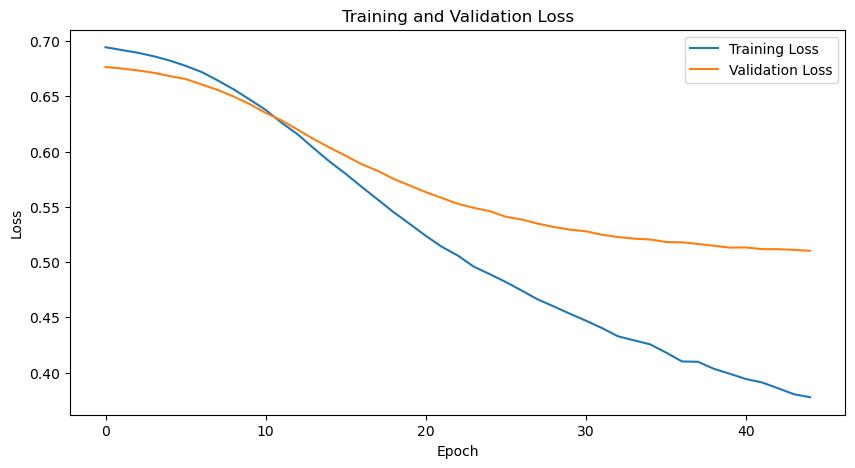

In [8]:
plt.figure(figsize=(10, 5))
plt.plot(range(num_epochs), train_losses, label='Training Loss')
plt.plot(range(num_epochs), val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.show()

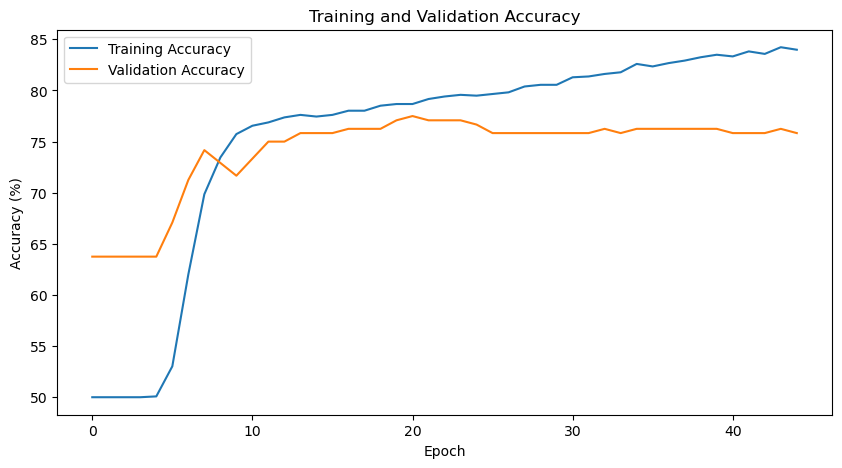

In [9]:
plt.figure(figsize=(10, 5))
plt.plot(range(num_epochs), train_accuracies, label='Training Accuracy')
plt.plot(range(num_epochs), val_accuracies, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.title('Training and Validation Accuracy')
plt.show()

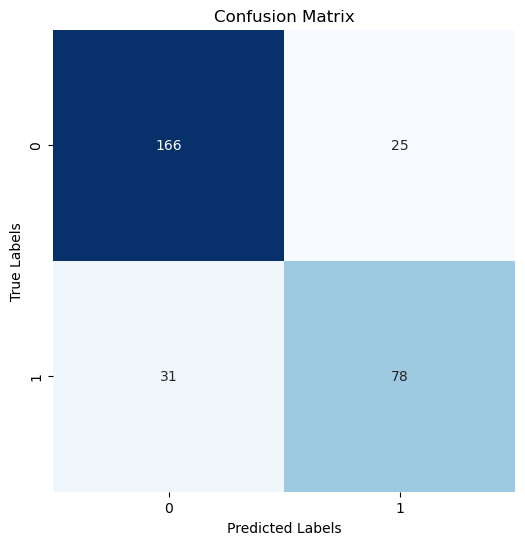

Classification Report:
               precision    recall  f1-score   support

     Class 0       0.84      0.87      0.86       191
     Class 1       0.76      0.72      0.74       109

    accuracy                           0.81       300
   macro avg       0.80      0.79      0.80       300
weighted avg       0.81      0.81      0.81       300

AUC : 0.8145
Overall Precision: 0.8000
Overall Recall: 0.7924
Overall F1-score: 0.7958
Sensitivity (True Positive Rate): 0.7156
Specificity (True Negative Rate): 0.8691


In [10]:
def evaluate(model):
  model.eval()
  test_labels = []

  test_predictions = []
  proba=[]
  with torch.no_grad():
      for inputs, targets in test_loader:
          outputs = model(inputs)
          test_labels+=targets.tolist()
          _, predicted = torch.max(outputs, 1)
          test_predictions.extend(predicted.tolist())
          proba.append(outputs)

  test_predictions = torch.tensor(test_predictions, dtype=torch.long)


  cm = confusion_matrix(test_labels, test_predictions)


  plt.figure(figsize=(6, 6))
  sns.heatmap(cm, annot=True, cmap='Blues', fmt='d', cbar=False, square=True)
  plt.xlabel('Predicted Labels')
  plt.ylabel('True Labels')
  plt.title('Confusion Matrix')
  plt.show()


  target_names = ['Class 0', 'Class 1']
  classification_rep = classification_report(test_labels, test_predictions, target_names=target_names)
  print('Classification Report:\n', classification_rep)

  proba=torch.cat(proba,dim=0).cpu().numpy()
  auc_value = roc_auc_score(test_labels, proba[:,1])

  print(f'AUC : {auc_value:.4f}')

  precision = precision_score(test_labels, test_predictions, average='macro')
  recall = recall_score(test_labels, test_predictions, average='macro')
  f1 = f1_score(test_labels, test_predictions, average='macro')

  print(f'Overall Precision: {precision:.4f}')
  print(f'Overall Recall: {recall:.4f}')
  print(f'Overall F1-score: {f1:.4f}')



  tn, fp, fn, tp = cm.ravel()
  sensitivity = tp / (tp + fn)
  specificity = tn / (tn + fp)

  print(f'Sensitivity (True Positive Rate): {sensitivity:.4f}')
  print(f'Specificity (True Negative Rate): {specificity:.4f}')


evaluate(model)